In [2]:

# imports
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

# Leitura do dataset
students_df = pd.read_csv("predict_students_dropout_and_academic_success.csv", sep = ";")
students_df.columns = students_df.columns.str.strip()


In [3]:

# Separação da coluna target 
y = students_df["Target"]
students_df.drop("Target", axis = 1, errors = "ignore", inplace = True)


In [4]:

# Normalização dos dados com técnica Min-max
scaler = MinMaxScaler()
scaled_students_df = pd.DataFrame(scaler.fit_transform(students_df), columns = students_df.columns)


In [8]:

# K-MEANS
# função para plotagem de k-means para qualquer k 
def plotar_kmeans(k):
    # Algoritmo k-means
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 'auto')
    clusters = kmeans.fit_predict(scaled_students_df)

    # Método PCA para visualização gráfica 3D
    pca = PCA(n_components = 3)
    principalComponents = pca.fit_transform(scaled_students_df)
    pca_df = pd.DataFrame(
        data = principalComponents,
        columns = ['principal component 1', 'principal component 2', 'principal component 3'])

    graphic_kmeans_df = pca_df.copy()
    graphic_kmeans_df['Agrupamentos'] = clusters.astype(str)

    fig = px.scatter_3d(
        graphic_kmeans_df,
        x = 'principal component 1',
        y = 'principal component 2',
        z = 'principal component 3',
        color = 'Agrupamentos',
        opacity = 0.5,
        title = f'K-Means (k = {k})')
    fig.update_traces(marker = dict(size = 3))
    fig.update_layout(
        scene = dict(
            xaxis_title = f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)',
            yaxis_title = f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)',
            zaxis_title = f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}%)' ))
    fig.show()

# GMM
# função para plotagem do GMM para qualquer n
def plotar_gmm(n):
    # Algoritmo GMM
    gmm = GaussianMixture(n_components = n, random_state = 42, n_init = 1)
    clusters = gmm.fit_predict(scaled_students_df)

    # Método PCA para visualização gráfica 3D
    pca = PCA(n_components = 3)
    principalComponents = pca.fit_transform(scaled_students_df)
    pca_df = pd.DataFrame(
        data = principalComponents,
        columns = ['principal component 1', 'principal component 2', 'principal component 3'])

    graphic_gmm_df = pca_df.copy()
    graphic_gmm_df['Agrupamentos'] = clusters.astype(str)
    fig = px.scatter_3d(
        graphic_gmm_df,
        x = 'principal component 1',
        y = 'principal component 2',
        z = 'principal component 3',
        color = 'Agrupamentos',
        opacity = 0.5,
        title = f'GMM (n_components = {n})')
    fig.update_traces(marker = dict(size = 3))
    fig.update_layout(
        scene = dict(
            xaxis_title = f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)',
            yaxis_title = f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)',
            zaxis_title = f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}%)' ))
    fig.show()


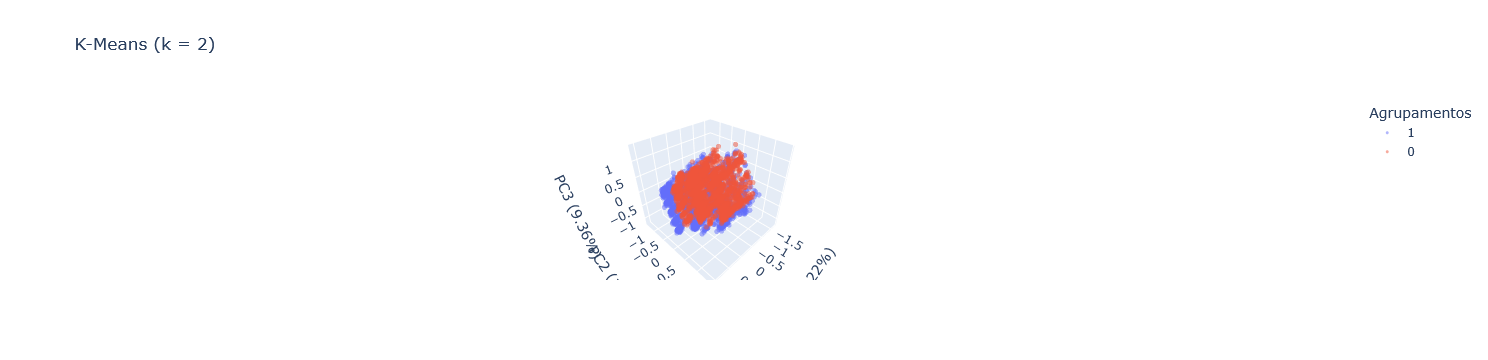

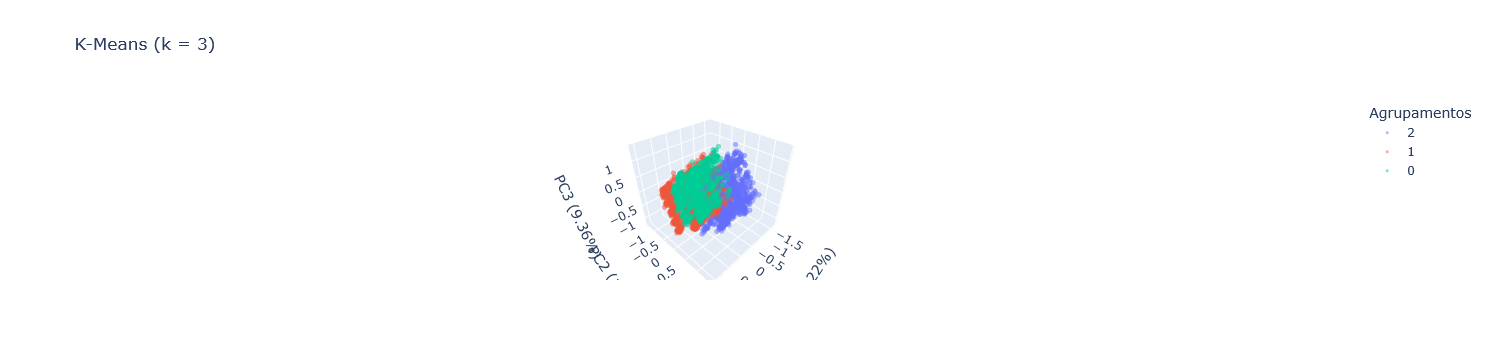

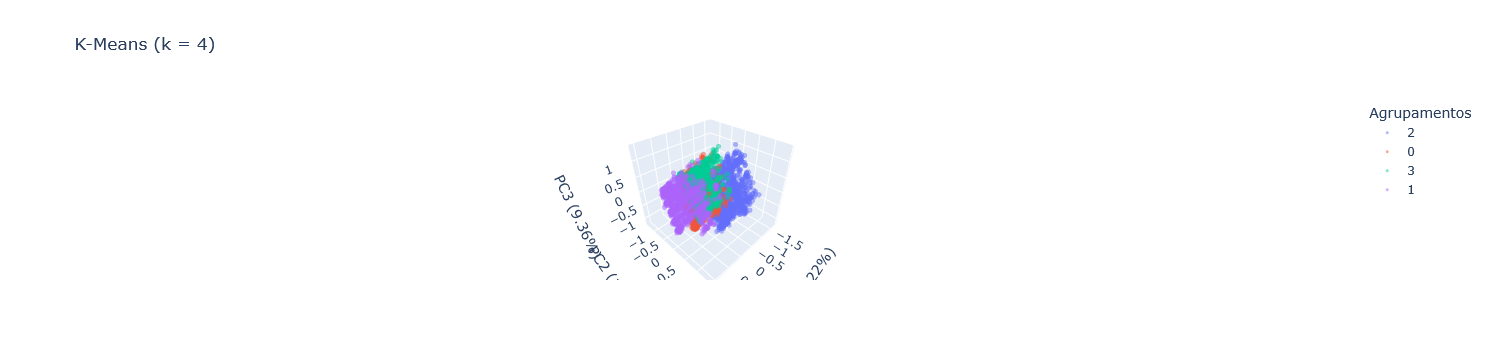

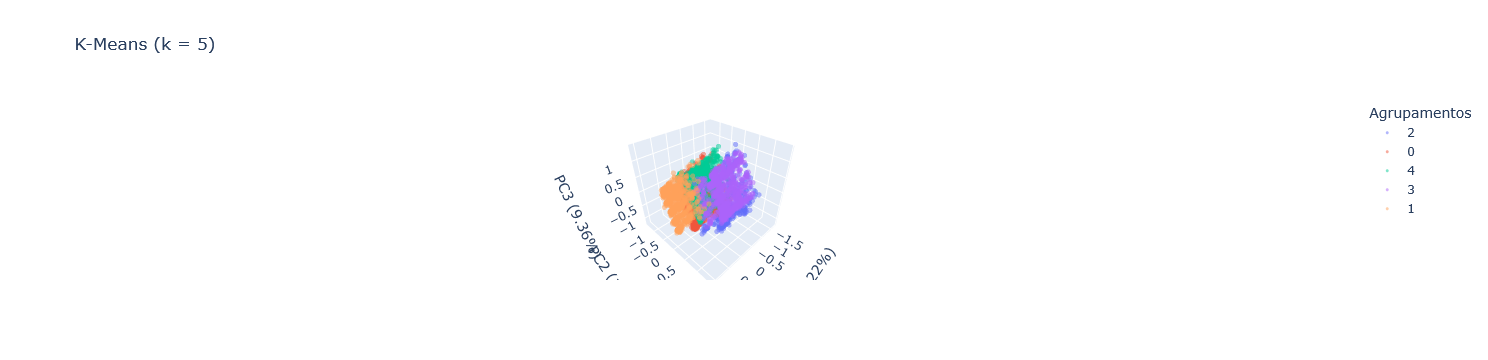

In [9]:

# testes de k-means com diferentes valors de k
plotar_kmeans(k=2)
plotar_kmeans(k=3)
plotar_kmeans(k=4)
plotar_kmeans(k=5)


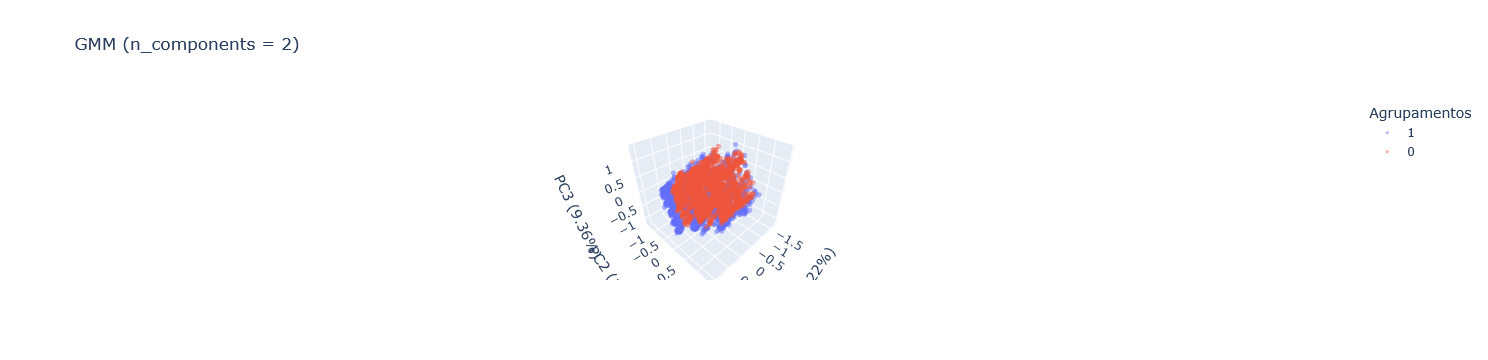

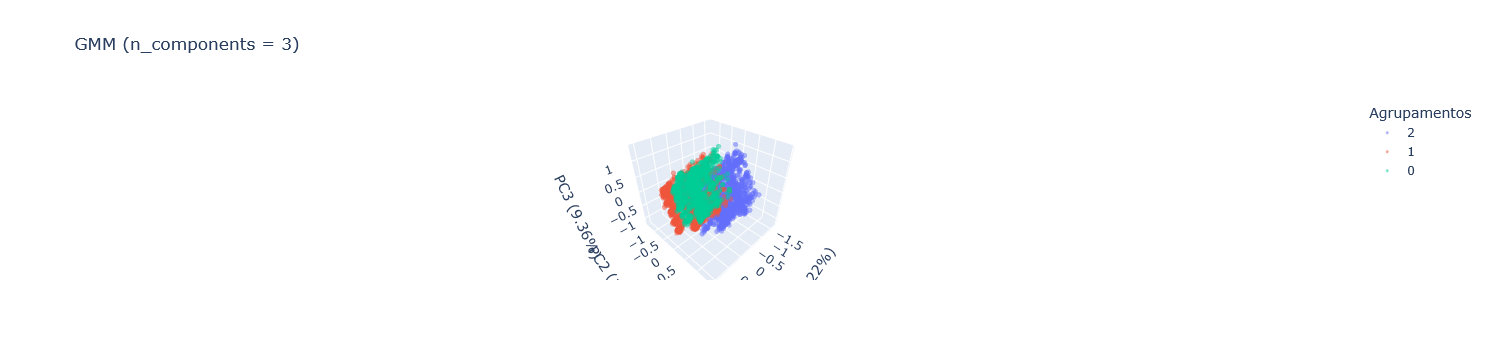

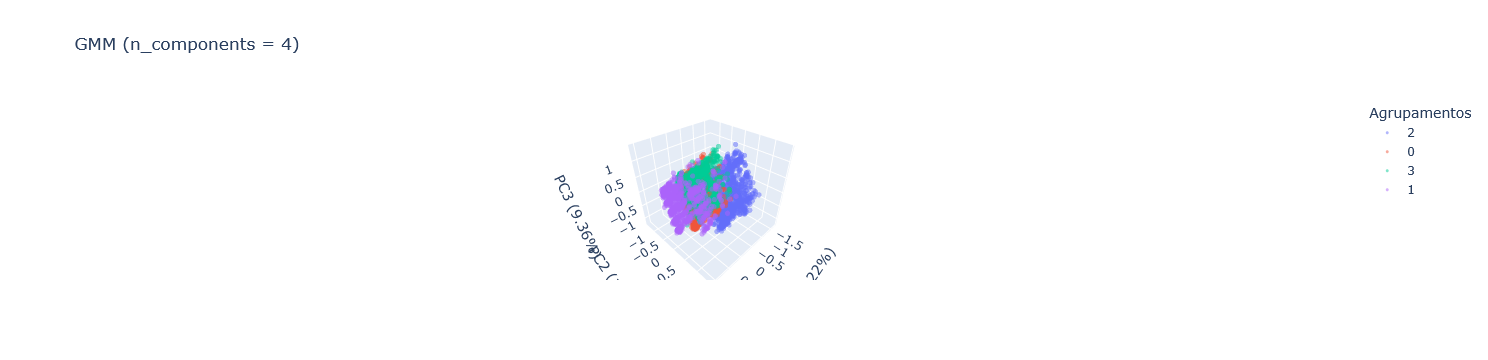

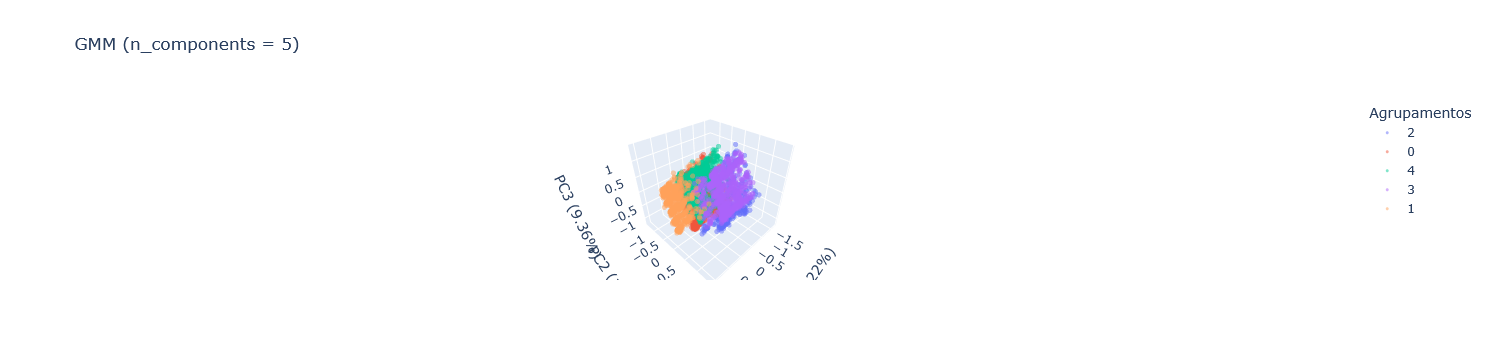

In [10]:

# testes de gmm com diferentes valores de n 
plotar_gmm(n=2)
plotar_gmm(n=3)
plotar_gmm(n=4)
plotar_gmm(n=5)
